## Python For Machine Learning Fall 2025
---
# MLP from Scratch in PyTorch

# MLP from Scratch in PyTorch

In this notebook, we'll build a complete Multi-Layer Perceptron (MLP) from the ground up using only basic PyTorch tensors. We will **not** use the `torch.nn` module, `nn.Module`, `nn.Linear`, or any pre-built optimizers like `torch.optim`.

**Our goal:** Build a neural network that can classify three species of Palmer Penguins.

**We will cover:**
1.  **Data Loading:** Loading and preprocessing the Iris dataset.
2.  **Model Definition:** Manually defining all parameters (weights and biases).
3.  **Activation Function:** Implementing the ReLU activation function from scratch.
4.  **Forward Pass:** Writing the function for the forward pass.
5.  **Loss Function:** Implementing the Cross-Entropy Loss from scratch.
6.  **Training Loop:** Manually implementing the training steps:
    * Calculating the loss.
    * Using PyTorch's `autograd` to get gradients (`loss.backward()`).
    * Manually updating our weights using gradient descent.
7.  **Testing:** Evaluating our trained model on the test set.

## 1. Imports Libaries
First, let's import the necessary libraries. We'll use `torch` for tensor operations and `autograd`, `seaborn` for dataset and visualization, `sklearn` for the data splitting, and `pandas` for loading and preprocessing.

In [12]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load and Process the Data

This step is more involved than with the Iris dataset, as we have to:
1.  Load the dataset from Seaborn.
2.  **Handle missing values** (we'll just drop them for simplicity).
3.  **Encode the target** (our `y`): 'species' will be mapped from strings to integers (0, 1, 2).
4.  **Encode categorical features** (our `X`): 'island' and 'sex' will be one-hot encoded.
5.  **Scale numerical features** (our `X`): We'll scale the measurements to have a mean of 0 and standard deviation of 1.
6.  Combine the scaled numerical features and one-hot encoded categorical features to create our final feature matrix `X`.

In [13]:
from IPython.display import Image, display

image_url = "https://tkoomar.github.io/post/tt-palmer-penguins/featured_huc6cf4a21090aa2ea134ebf239881872e_167000_720x0_resize_lanczos_2.png"
display(Image(url=image_url))

In [14]:
penguins = sns.load_dataset('penguins')

# Handle missing values
penguins = penguins.dropna()

species_map = {species: i for i, species in enumerate(penguins['species'].unique())}
species_names = list(species_map.keys())
y_raw = penguins['species'].map(species_map)

X_num_raw = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
X_cat_raw = penguins[['island', 'sex']]

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_raw)

X_cat_onehot = pd.get_dummies(X_cat_raw, drop_first=True)

# Convert boolean columns in X_cat_onehot to integers
X_cat_onehot = X_cat_onehot.astype(int)

X_all = pd.concat([
    pd.DataFrame(X_num_scaled, columns=X_num_raw.columns),
    X_cat_onehot.reset_index(drop=True)
], axis=1)

# Convert to PyTorch tensors
X = torch.tensor(X_all.values, dtype=torch.float32)
y = torch.tensor(y_raw.values, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"--- Data Shapes ---")
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

print(f"\n--- Model I/O ---")
print(f"Input features: {X_all.shape[1]} (Columns: {list(X_all.columns)})")
print(f"Output classes: {len(species_names)} (Classes: {species_names})")

--- Data Shapes ---
Training data shape: torch.Size([266, 7])
Training labels shape: torch.Size([266])
Test data shape: torch.Size([67, 7])
Test labels shape: torch.Size([67])

--- Model I/O ---
Input features: 7 (Columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_Male'])
Output classes: 3 (Classes: ['Adelie', 'Chinstrap', 'Gentoo'])


## 3. Model Definition (From Scratch)

Our MLP will have one hidden layer.
* **Input Layer:** `input_size` (which we just calculated as 7)
* **Hidden Layer:** 10 neurons (this is arbitrary,
   we can tune it)
* **Output Layer:** 3 neurons (one for each penguin species)

The model architecture is: `Linear -> ReLU -> Linear`

We must set `requires_grad=True` for all parameters we want to train.

In [15]:
input_size = X_train.shape[1]  # This is 7
hidden_size = 10
output_size = len(species_names) # This is 3

# Layer 1: Input (7) -> Hidden (10)
W1 = torch.randn(input_size, hidden_size, dtype=torch.float32) * 0.01
b1 = torch.zeros(hidden_size, dtype=torch.float32)

# Layer 2: Hidden (10) -> Output (3)
W2 = torch.randn(hidden_size, output_size, dtype=torch.float32) * 0.01
b2 = torch.zeros(output_size, dtype=torch.float32)

W1.requires_grad_()
b1.requires_grad_()
W2.requires_grad_()
b2.requires_grad_()

parameters = [W1, b1, W2, b2]

print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"b2 shape: {b2.shape}")

W1 shape: torch.Size([7, 10])
b1 shape: torch.Size([10])
W2 shape: torch.Size([10, 3])
b2 shape: torch.Size([3])


## 4. Activation and Loss Functions (From Scratch)

These functions are identical to before. They don't depend on the dataset, only on the math!

In [16]:
def relu(x):
    """Rectified Linear Unit (ReLU) activation function"""
    return torch.max(torch.tensor(0.0), x)

def log_softmax(logits):
    """Computes Log-Softmax, a numerically stable version of log(softmax(x))"""
    # Subtract the max for numerical stability (prevents overflow)
    max_logits = torch.max(logits, dim=1, keepdim=True).values
    exps = torch.exp(logits - max_logits)
    sum_exps = torch.sum(exps, dim=1, keepdim=True)
    return logits - max_logits - torch.log(sum_exps)

def cross_entropy_loss(log_probs, targets):
    """Computes the Negative Log-Likelihood (NLL) Loss.
       When combined with log_softmax, this is the cross-entropy loss.
    """
    num_samples = targets.shape[0]
    correct_log_probs = log_probs.gather(dim=1, index=targets.unsqueeze(1))

    loss = -torch.mean(correct_log_probs)
    return loss

### 4.1 Softmax

Softmax is an activation function typically used as the **final layer** in a **multi-class** classification neural network. Its job is to take a vector of raw, real-numbered scores (called **logits**) and convert them into a vector of **probabilities**.

**Key Properties:**
1.  Each output value is between 0 and 1.
2.  The sum of all output values is exactly 1.

This is incredibly useful because we can interpret the output as the model's *confidence* for each class. For example, if the output for a penguin is `[0.9, 0.08, 0.02]`, the model is 90% confident it's an "Adelie" (class 0), 8% confident it's a "Chinstrap" (class 1), and 2% confident it's a "Gentoo" (class 2).

The Softmax function for a single output $z_i$ (one logit in the output vector $z$) is defined as:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

In plain English, for each logit, you:
1.  **Exponentiate it** (take $e^{z_i}$). This makes all numbers positive.
2.  **Sum all** the exponentiated values to get a total.
3.  **Divide** the exponentiated value by this total sum.

#### A Simple Example:
Imagine our network's final layer outputs these logits:
`logits = [2.0, 1.0, 0.1]`

1.  **Exponentiate:**
    * $e^{2.0} \approx 7.39$
    * $e^{1.0} \approx 2.72$
    * $e^{0.1} \approx 1.11$

2.  **Sum the total:**
    * `Total = 7.39 + 2.72 + 1.11 = 11.22`

3.  **Divide by total:**
    * `Prob(class 0) = 7.39 / 11.22 = 0.659`
    * `Prob(class 1) = 2.72 / 11.22 = 0.242`
    * `Prob(class 2) = 1.11 / 11.22 = 0.099`

**Output Probabilities:** `[0.659, 0.242, 0.099]`
(Note: They sum to 1.0!)

### 4.2 Log Softmax

While Softmax is great conceptually, it has a major problem in practice: **numerical instability**.

* **Overflow:** If your logits are large (e.g., `[1000, 1001]`), $e^{1000}$ is an astronomically large number that computers can't store (it becomes `inf`). The calculation becomes `inf / inf`, which results in `NaN` (Not a Number).
* **Underflow:** If your logits are very negative (e.g., `[-1000, -1001]`), $e^{-1000}$ is so tiny it rounds to `0`. The calculation becomes `0 / 0`, which is also `NaN`.

The `log_softmax` function is a clever combination of `log()` and `softmax()` that performs the calculation in a much more stable way (as seen in our `log_softmax` implementation, which subtracts the max logit).

**The key takeaway:**
Our loss function, `cross_entropy_loss`, actually expects **log-probabilities** as input, not raw probabilities.

`Cross-Entropy Loss = LogSoftmax + NLLLoss`

By implementing `log_softmax` (which gives log-probabilities) and `cross_entropy_loss` (which is technically just the **Negative Log-Likelihood Loss** part), we created the standard, numerically stable training pipeline for a classification model.

### 4.3 Cross-Entropy Loss

Cross-Entropy Loss is the "referee" for our model. Its job is to measure exactly **how bad** our model's predictions are compared to the **true labels**. It's the most common loss function used for multi-class classification problems.

Cross-Entropy Loss works by comparing two probability distributions:
1.  **The "Ground Truth" Distribution:** This is what the label *should* be. In classification, we represent this as a **one-hot vector**. If we have 3 classes (Adelie, Chinstrap, Gentoo) and the correct answer is "Chinstrap" (class 1), the one-hot vector is:
    `Truth = [0, 1, 0]`
    (0% Adelie, 100% Chinstrap, 0% Gentoo)

2.  **The "Model's Prediction" Distribution:** This is the output of our `softmax` function, which is a vector of probabilities. A good prediction might look like:
    `Prediction = [0.1, 0.8, 0.1]`
    (10% Adelie, 80% Chinstrap, 10% Gentoo)

A **low loss** (good score) results when these two distributions are very similar.
A **high loss** (bad score) results when they are very different.

* **Good Prediction:** `Truth = [0, 1, 0]` vs. `Prediction = [0.1, 0.8, 0.1]` -> **Low Loss**
* **Bad Prediction:** `Truth = [0, 1, 0]` vs. `Prediction = [0.8, 0.1, 0.1]` -> **High Loss**

The full mathematical formula for cross-entropy is:

$$H(p, q) = -\sum_i p(i) \log(q(i))$$

* $p(i)$ is the true probability for class $i$ (from the one-hot `Truth` vector).
* $q(i)$ is the model's predicted probability for class $i$ (from the `Prediction` vector).

This looks complex, but watch what happens with our one-hot `Truth` vector `p = [0, 1, 0]`:

* For class 0 ("Adelie"): $p(0) \log(q(0)) = \mathbf{0} \times \log(0.1) = 0$
* For class 1 ("Chinstrap"): $p(1) \log(q(1)) = \mathbf{1} \times \log(0.8) = \log(0.8)$
* For class 2 ("Gentoo"): $p(2) \log(q(2)) = \mathbf{0} \times \log(0.1) = 0$

The entire, scary-looking sum simplifies to just the term for the *correct class*!

$$\text{Loss} = -(\log(q_c))$$

Where $q_c$ is the model's predicted probability for the **correct class**.

This is the key takeaway: **Cross-Entropy Loss is just the negative logarithm of the probability our model assigned to the correct answer.** 🎯

Let's look at our examples again:
* **Good Prediction:** `[0.1, 0.8, 0.1]`. Correct class is 1.
    * Loss = $-\log(0.8) \approx \mathbf{0.22}$ (a low loss)
* **Bad Prediction:** `[0.8, 0.1, 0.1]`. Correct class is 1.
    * Loss = $-\log(0.1) \approx \mathbf{2.30}$ (a high loss)

The $-\log(x)$ function explodes as $x$ (the probability) gets closer to 0. This means the model is **heavily penalized** for being "confidently wrong," which forces it to learn quickly.

## 5. Forward Pass

This step defines the forward process, also known as the model. The calculation process we have implemented is actually independent of the data.

In [17]:
def forward(X):
    """Performs one forward pass through the network."""

    # Layer 1: Linear + ReLU
    # z1 = X @ W1 + b1  (where @ is matrix multiplication)
    z1 = torch.matmul(X, W1) + b1
    a1 = relu(z1)

    # Layer 2: Linear (these are the raw outputs, or 'logits')
    # z2 = a1 @ W2 + b2
    logits = torch.matmul(a1, W2) + b2

    return logits

## 6. The Training Loop

This is the core `autograd` and gradient descent logic. It is also 100% identical to the Iris notebook. This demonstrates how powerful and general this training pattern is.

1.  **Forward Pass:** Get predictions.
2.  **Compute Loss:** See how wrong the predictions are.
3.  **Backward Pass:** Call `loss.backward()` to calculate gradients.
4.  **Parameter Update:** Manually update weights with `torch.no_grad()`.

In [18]:
learning_rate = 0.05
epochs = 1500

losses = []

for epoch in range(epochs):

    logits = forward(X_train)

    log_probs = log_softmax(logits)
    loss = cross_entropy_loss(log_probs, y_train)
    losses.append(loss.item())

    for p in parameters:
        if p.grad is not None:
            p.grad.zero_()

    loss.backward()

    with torch.no_grad():
        for p in parameters:
            p -= learning_rate * p.grad

    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

Epoch 0/1500, Loss: 1.0986
Epoch 100/1500, Loss: 0.9119
Epoch 200/1500, Loss: 0.3844
Epoch 300/1500, Loss: 0.1687
Epoch 400/1500, Loss: 0.0733
Epoch 500/1500, Loss: 0.0441
Epoch 600/1500, Loss: 0.0317
Epoch 700/1500, Loss: 0.0250
Epoch 800/1500, Loss: 0.0209
Epoch 900/1500, Loss: 0.0182
Epoch 1000/1500, Loss: 0.0162
Epoch 1100/1500, Loss: 0.0146
Epoch 1200/1500, Loss: 0.0134
Epoch 1300/1500, Loss: 0.0125
Epoch 1400/1500, Loss: 0.0117


## Plot the Loss

Let's see how our loss curve looks.

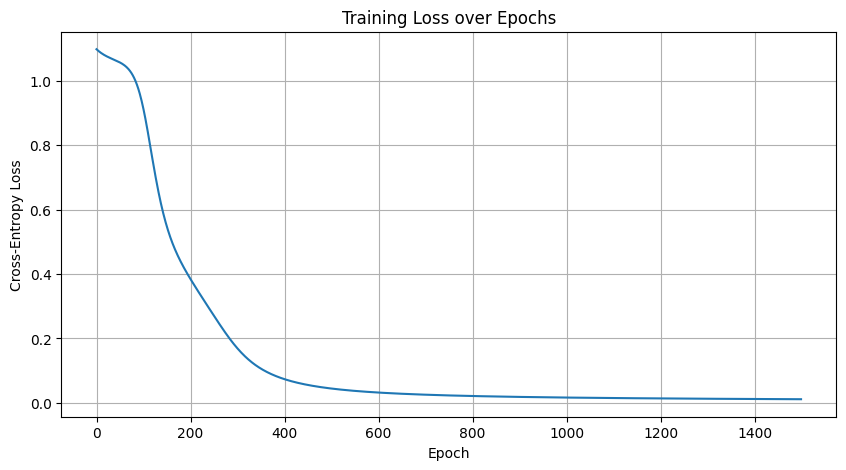

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()

## 7. Testing the Model

Let's evaluate our penguin classifier on the unseen test data. The process is the same:
1.  Run the `forward` pass on `X_test`.
2.  Get the predicted class by taking the `argmax` of the logits.
3.  Compare to the true labels `y_test` and calculate accuracy.

In [20]:
with torch.no_grad():
    test_logits = forward(X_test)

    _, predicted_labels = torch.max(test_logits, dim=1)

    correct_predictions = (predicted_labels == y_test).sum().item()
    total_predictions = y_test.shape[0]

    accuracy = 100 * correct_predictions / total_predictions

    print(f"Correct Predictions: {correct_predictions} / {total_predictions}")
    print(f"Test Accuracy: {accuracy:.2f}%")

print("\n--- Sample Predictions ---")
print(f"Predicted: {predicted_labels[:10]}")
print(f"Actual:    {y_test[:10]}")
print(f"\n(Classes: {species_map})")

Correct Predictions: 67 / 67
Test Accuracy: 100.00%

--- Sample Predictions ---
Predicted: tensor([0, 2, 0, 1, 0, 2, 2, 1, 1, 1])
Actual:    tensor([0, 2, 0, 1, 0, 2, 2, 1, 1, 1])

(Classes: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2})


## 8. Visualizing the Performance Metric

A confusion matrix is perfect for seeing which penguin species our model is getting mixed up.

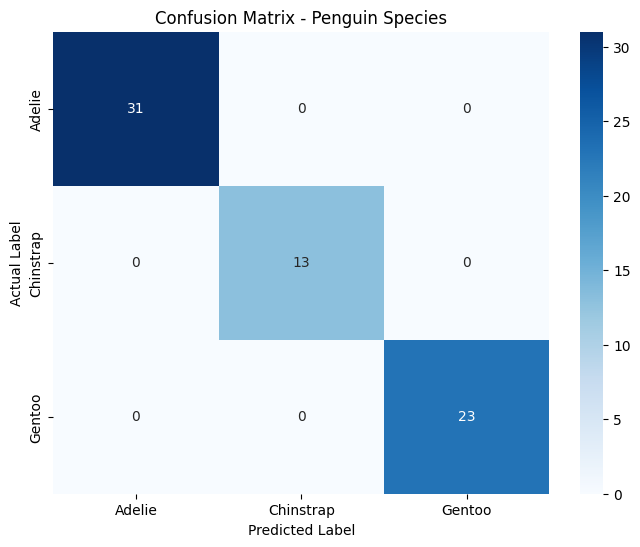

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test.numpy(), predicted_labels.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names,
            yticklabels=species_names)
plt.title('Confusion Matrix - Penguin Species')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()